In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics.pairwise import cosine_similarity,euclidean_distances

In [2]:
df = pd.read_csv('anime.csv')
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


## Data_description

In [3]:
# Data Description:

# Unique ID of each anime.
# Anime title.
# Anime broadcast type, such as TV, OVA, etc.
# anime genre.
# The number of episodes of each anime.
# The average rating for each anime compared to the number of users who gave ratings.

In [4]:
df.shape

(12294, 7)

In [5]:
df.size

86058

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [7]:
# episodes is stored as object in the data but it have to be in the numeric form so changing 
# # the episode data type into the numerical data type

In [8]:
# episodes have some value stores as unknown , so to don't get error while conversion we will
# use 'coerce'.

In [9]:
df['episodes'] = pd.to_numeric(df['episodes'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  11954 non-null  float64
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 672.5+ KB


## Checking null values 

In [10]:
df.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes    340
rating      230
members       0
dtype: int64

In [11]:
df.fillna(
    {
        'genre' : df['genre'].mode()[0],
        'type' : df['type'].mode()[0],
        'episodes' : df['episodes'].median(),
        'rating':df['rating'].median()
    },inplace = True
)
df.isnull().sum()

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

## Checking duplicates

In [12]:
# checking duplicates inside the data 
df.duplicated().sum()

np.int64(0)

In [13]:
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1.0,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64.0,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51.0,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24.0,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51.0,9.16,151266


## Unique_entry

In [14]:
print('The total unique anime_id inside the data set :- ',len(df['anime_id'].unique()))

The total unique anime_id inside the data set :-  12294


In [15]:
print('The total unique anime inside the data set :- ',len(df['name'].unique()))

The total unique anime inside the data set :-  12292


In [16]:
print('The total unique rating inside the data set :- ',len(df['rating'].unique()))

The total unique rating inside the data set :-  598


In [17]:
print('The total unique genre inside the data set :- ',len(df['genre'].unique()))

The total unique genre inside the data set :-  3264


In [18]:
print('The total unique type inside the data set :- ',len(df['type'].unique()))

The total unique type inside the data set :-  6


In [19]:
df['type'].unique()

array(['Movie', 'TV', 'OVA', 'Special', 'Music', 'ONA'], dtype=object)

In [20]:
print('The total unique episode inside the data set :- ',len(df['episodes'].unique()))

The total unique episode inside the data set :-  186


In [21]:
print('The total unique members inside the data set :- ',len(df['members'].unique()))

The total unique members inside the data set :-  6706


### Rating

In [22]:
print('The highest rating inside the data set :- ',df['rating'].max())

The highest rating inside the data set :-  10.0


In [23]:
print('The lowest rating inside the data set :- ', df['rating'].min())

The lowest rating inside the data set :-  1.67


In [24]:
print('The average rating is :- ',df['rating'].mean())

The average rating is :-  6.47569952822515


In [25]:
mean_rating = df['rating'].mean()
print("Number of anime with rating below the average:", len(df[df['rating'] < mean_rating]))

Number of anime with rating below the average: 5537


In [26]:
print("Number of anime with rating above the average:", len(df[df['rating'] > mean_rating]))

Number of anime with rating above the average: 6757


In [27]:
# Distribution of rating

array([[<Axes: title={'center': 'rating'}>]], dtype=object)

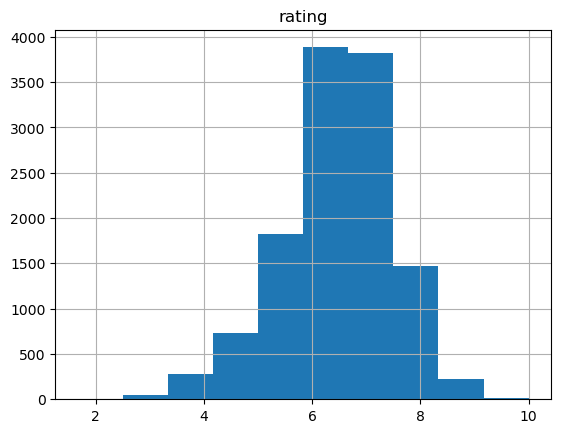

In [28]:
df.hist('rating')

The highest rating anime is Taka no Tsume 8: Yoshida-kun no X-Files The lowest rating anime is Platonic Chain: Ansatsu Jikkouchuu

In [29]:
# Top 11 highly watched anime by the audience
df.groupby('name')['rating'].mean().sort_values(ascending=False)[:11]

name
Taka no Tsume 8: Yoshida-kun no X-Files                      10.00
Spoon-hime no Swing Kitchen                                   9.60
Mogura no Motoro                                              9.50
Kimi no Na wa.                                                9.37
Kahei no Umi                                                  9.33
Fullmetal Alchemist: Brotherhood                              9.26
Gintama°                                                      9.25
Yakusoku: Africa Mizu to Midori                               9.25
Steins;Gate                                                   9.17
Gintama&#039;                                                 9.16
Haikyuu!!: Karasuno Koukou VS Shiratorizawa Gakuen Koukou     9.15
Name: rating, dtype: float64

In [30]:
# Top 11 highest gener watched by the audience
df.groupby('genre')['rating'].mean().sort_values(ascending=False)[:11]

genre
Action, Adventure, Drama, Fantasy, Magic, Military, Shounen                     9.260
Drama, Fantasy, Romance, Slice of Life, Supernatural                            9.060
Drama, School, Shounen                                                          9.050
Adventure, Drama, Supernatural                                                  8.930
Drama, Music, Romance, School, Shounen                                          8.920
Action, Mecha, Military, School, Sci-Fi, Super Power                            8.830
Action, Drama, Historical, Martial Arts, Romance, Samurai                       8.830
Comedy, Mystery, Romance, School, Sci-Fi, Supernatural                          8.810
Comedy, Mystery, Romance, Supernatural, Vampire                                 8.800
Comedy, Drama, School, Shounen, Slice of Life                                   8.770
Adventure, Fantasy, Historical, Mystery, Seinen, Slice of Life, Supernatural    8.735
Name: rating, dtype: float64


The highest gener watched is Action, Adventure, Drama, Fantasy, Magic, Military, Shounen Adventure, Fantasy, Historical, Mystery, Seinen, Slice of Life, and Supernatural  


In [31]:
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1.0,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64.0,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51.0,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24.0,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51.0,9.16,151266


## Data preprocessing

In [34]:
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1.0,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64.0,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51.0,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24.0,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51.0,9.16,151266


In [35]:
features = df[['genre','type','episodes','rating','members']]

In [36]:
features.head()

,genre,type,episodes,rating,members
0,"Drama, Romance, School, Supernatural",Movie,1.0,9.37,200630
1,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64.0,9.26,793665
2,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51.0,9.25,114262
3,"Sci-Fi, Thriller",TV,24.0,9.17,673572
4,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51.0,9.16,151266


In [37]:
features.shape

(12294, 5)

In [39]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   genre     12294 non-null  object 
 1   type      12294 non-null  object 
 2   episodes  12294 non-null  float64
 3   rating    12294 non-null  float64
 4   members   12294 non-null  int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 480.4+ KB


In [43]:
genre_dummies = df['genre'].str.get_dummies(sep=', ')
genre_dummies.head()

,Action,Adventure,Cars,Comedy,Dementia,Demons,Drama,Ecchi,Fantasy,Game,...,Shounen Ai,Slice of Life,Space,Sports,Super Power,Supernatural,Thriller,Vampire,Yaoi,Yuri
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,1,1,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [46]:
type_dummies = pd.get_dummies(df['type'], prefix='type',dtype='int')
type_dummies.head()

,type_Movie,type_Music,type_ONA,type_OVA,type_Special,type_TV
0,1,0,0,0,0,0
1,0,0,0,0,0,1
2,0,0,0,0,0,1
3,0,0,0,0,0,1
4,0,0,0,0,0,1


In [49]:
# scaling numerical columns
from sklearn.preprocessing import MinMaxScaler
min_max = MinMaxScaler()

In [50]:
df[['episodes', 'rating', 'members']] = min_max.fit_transform(df[['episodes', 'rating', 'members']])

In [51]:
df[['episodes', 'rating', 'members']].head()

,episodes,rating,members
0,0.000000,0.924370,0.197872
1,0.034673,0.911164,0.782770
2,0.027518,0.909964,0.112689
3,0.012658,0.900360,0.664325
4,0.027518,0.899160,0.149186


In [52]:
features = pd.concat(
    [
        genre_dummies,
        type_dummies,
        df[['episodes', 'rating', 'members']]
    ],
    axis=1
)

In [53]:
features.head()

,Action,Adventure,Cars,Comedy,Dementia,Demons,Drama,Ecchi,Fantasy,Game,...,Yuri,type_Movie,type_Music,type_ONA,type_OVA,type_Special,type_TV,episodes,rating,members
0,0,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0.000000,0.924370,0.197872
1,1,1,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,1,0.034673,0.911164,0.782770
2,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0.027518,0.909964,0.112689
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0.012658,0.900360,0.664325
4,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0.027518,0.899160,0.149186


In [54]:
features.index = df['name']

In [55]:
features.head()

,Action,Adventure,Cars,Comedy,Dementia,Demons,Drama,Ecchi,Fantasy,Game,...,Yuri,type_Movie,type_Music,type_ONA,type_OVA,type_Special,type_TV,episodes,rating,members
name,,,,,,,,,,,,,,,,,,,,,
Kimi no Na wa.,0,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0.000000,0.924370,0.197872
Fullmetal Alchemist: Brotherhood,1,1,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,1,0.034673,0.911164,0.782770
Gintama°,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0.027518,0.909964,0.112689
Steins;Gate,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0.012658,0.900360,0.664325
Gintama&#039;,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0.027518,0.899160,0.149186


## Cosin similarity 

In [57]:
features_copy = features.copy()
features_copy.head()

,Action,Adventure,Cars,Comedy,Dementia,Demons,Drama,Ecchi,Fantasy,Game,...,Yuri,type_Movie,type_Music,type_ONA,type_OVA,type_Special,type_TV,episodes,rating,members
name,,,,,,,,,,,,,,,,,,,,,
Kimi no Na wa.,0,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0.000000,0.924370,0.197872
Fullmetal Alchemist: Brotherhood,1,1,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,1,0.034673,0.911164,0.782770
Gintama°,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0.027518,0.909964,0.112689
Steins;Gate,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0.012658,0.900360,0.664325
Gintama&#039;,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0.027518,0.899160,0.149186


In [58]:
cos_sin = cosine_similarity(features_copy)

In [59]:
cos_sin.shape

(12294, 12294)

In [60]:
cos_sin[0]

array([1.        , 0.26769269, 0.11961324, ..., 0.10011476, 0.10300589,
       0.3938932 ], shape=(12294,))

In [82]:
import re

def clean(text):
    return re.sub(r'[^a-zA-Z0-9 ]', '', text).lower().strip()

cleaned_index = features_copy.index.to_series().apply(clean)

def recommended_anime(movie_name):

    movie_name = clean(movie_name)

    if movie_name in cleaned_index.values:

        index = np.where(cleaned_index == movie_name)[0][0]

        similar = sorted(
            list(enumerate(cos_sin[index])),
            reverse=True,
            key=lambda x: x[1]
        )[1:6]

        print("="*60)
        print(f" Anime Selected : {features_copy.index[index]}")
        print("="*60)
        print("\n You may also like:\n")

        for i, movie in enumerate(similar, 1):
            print(f"{i}. {features_copy.index[movie[0]]}")

        print("\nHappy Watching!")
        print("="*60)

    else:
        print("Sorry! Anime not found in the database.")

In [83]:
recommended_anime('one piece =')

 Anime Selected : One Piece

 You may also like:

1. Digimon Frontier
2. Dragon Ball Z
3. Dragon Ball Kai
4. Dragon Ball Super
5. Dragon Ball Kai (2014)

Happy Watching!


In [84]:
# with different threshold

In [99]:
import re

def clean(text):
    return re.sub(r'[^a-zA-Z0-9 ]', '', text).lower().strip()

cleaned_index = features_copy.index.to_series().apply(clean)

def recommended_anime(movie_name, threshold=0.7):

    movie_name = clean(movie_name)

    if movie_name in cleaned_index.values:

        index = np.where(cleaned_index == movie_name)[0][0]

        # Apply threshold
        similar = [
            (i, score)
            for i, score in enumerate(cos_sin[index])
            if score >= threshold and i != index
        ]

        # Sort by similarity score
        similar = sorted(similar, key=lambda x: x[1], reverse=True)[:5]

        print("="*60)
        print(f"Anime Selected : {features_copy.index[index]}")
        print("="*60)
        print(f"\nRecommendations (Threshold = {threshold})\n")

        if len(similar) == 0:
            print("No recommendations found for this threshold.")
        else:
            for i, movie in enumerate(similar, 1):
                print(f"{i}. {features_copy.index[movie[0]]} (Score: {movie[1]:.3f})")

        print("\nHappy Watching!")
        print("="*60)

    else:
        print("Sorry! Anime not found in the database.")

In [100]:
recommended_anime("One Piece", threshold=0.4)

Anime Selected : One Piece

Recommendations (Threshold = 0.4)

1. Digimon Frontier (Score: 0.930)
2. Dragon Ball Z (Score: 0.885)
3. Dragon Ball Kai (Score: 0.877)
4. Dragon Ball Super (Score: 0.876)
5. Dragon Ball Kai (2014) (Score: 0.874)

Happy Watching!


In [101]:
recommended_anime("Naruto", threshold=0.7)

Anime Selected : Naruto

Recommendations (Threshold = 0.7)

1. Naruto: Shippuuden (Score: 0.997)
2. Katekyo Hitman Reborn! (Score: 0.912)
3. Dragon Ball Z (Score: 0.873)
4. Bleach (Score: 0.856)
5. Dragon Ball Kai (Score: 0.856)

Happy Watching!


## Analysis 

1. The recommendation system successfully recommends anime with similar genres, ratings, and broadcast types.
2. Cosine similarity works well for content-based recommendations because it measures similarity between feature vectors.

## 1. Can you explain the difference between User-Based and Item-Based Collaborative Filtering?

User-Based Collaborative Filtering recommends items by finding users with similar preferences. It assumes that users who have liked similar items in the past will also like similar items in the future. For example, if two users have similar anime preferences, the system recommends anime liked by one user to the other.

Item-Based Collaborative Filtering recommends items by finding similar items instead of similar users. It assumes that if many users liked two items together, those items are similar. For example, if users who watched Naruto also watched Bleach, then Bleach will be recommended to users who watched Naruto.

Difference:

User-Based Collaborative Filtering compares users to recommend items.
Item-Based Collaborative Filtering compares items to recommend similar items.
User-Based is less efficient for large datasets because user preferences change frequently.
Item-Based is more efficient and scalable since item similarities remain relatively stable.

## 2. What is Collaborative Filtering, and how does it work?

Collaborative Filtering is a recommendation technique that suggests items to users based on the preferences and behavior of other users. It works on the idea that users with similar interests are likely to enjoy similar items.

The process involves collecting user-item interaction data, such as ratings, purchases, or watch history. The system then calculates similarities between users or items and predicts which items a user is likely to prefer. Finally, it recommends the most relevant items based on these similarity scores.

Collaborative Filtering is widely used in recommendation systems for movies, music, e-commerce, and online streaming platforms.